In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing import constants as K
from chicago_housing.data.load import load_training_data
from chicago_housing.data import wrangling, distributions
from chicago_housing.features import derive
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

### 1. EDA — profiling, re-profiling & distributions
Profile the raw scoped frame, record dtype/drop fixes in `constants.py`, re-profile to confirm, then read distribution shapes to flag transform candidates. **No rows are dropped here.**

In [1]:
# Load raw SF parquet + carve the Chicago / SF / 2022-2025 scope
raw = load_training_data(property_type='sf', columns=wrangling.analysis_columns())   # read (kept for §5)
df = wrangling.scope_filter(raw)
print(f"Chicago sales dataframe has shape: {df.shape}")

NameError: name 'load_training_data' is not defined

In [3]:
# Step 1 - Recode variables
df = wrangling.recode_categoricals(df)

recode_categoricals: 10 col(s) -> labels: ['char_air', 'char_attic_fnsh', 'char_attic_type', 'char_bsmt', 'char_bsmt_fin', 'char_gar1_att', 'char_gar1_size', 'char_heat', 'char_porch', 'char_roof_cnst']


In [4]:
# Step 2 — profile the pruned candidate columns: raw dtypes, missingness, degeneracy.
# (engineered cols aren't in the raw frame yet, so exclude K.ENGINEERED.)
candidate = (
    K.BLOCK_A_STRUCTURE
    + [c for c in K.BLOCK_B_LOCATION if c not in K.ENGINEERED]
    + K.DEMOGRAPHICS
    + ["meta_sale_price"]
)
wrangling.profile_columns(df, candidate)

,column,role,dtype,pct_missing,n_missing,n_unique,pct_modal,modal_value
0,acs5_median_household_renter_occupied_gross_rent,acs5,float64,0.031,1311,1103,0.007,993.000
1,acs5_median_income_household_past_year,acs5,float64,0.008,321,2087,0.004,"70,232.000"
2,acs5_median_age_total,acs5,float64,0.000,1,312,0.012,42.200
3,acs5_percent_education_bachelor,acs5,float64,0.000,1,2174,0.004,0.278
4,acs5_percent_household_owner_occupied,acs5,float64,0.000,1,2174,0.004,0.865
5,acs5_percent_income_below_poverty_level,acs5,float64,0.000,1,2175,0.004,0.099
6,char_gar1_att,char,category,0.003,134,2,0.922,No
7,char_attic_fnsh,char,category,0.002,98,3,0.807,None
8,char_porch,char,category,0.002,96,3,0.789,None
9,char_bsmt_fin,char,category,0.001,49,3,0.684,Unfinished


In [5]:
# Step 3 — fixes discovered from the profile above, recorded in constants.py:
#   CHANGE_DTYPE_FROM_FLOAT_TO_INT — counts/years stored as float -> Int64
#   DROP_REDUNDANT_COLS_WRANGLING  — redundant / superseded columns
# NOTE: 
# 1. char_attic_fnsh because ~80% values are None
# 2. Same reason for char_porch and char_attic_type
# 3. Values not meaningful in case of char_bsmt_fin, char_roof_cnst 
print("float -> Int64:", K.CHANGE_DTYPE_FROM_FLOAT_TO_INT)
print("drop redundant:", K.DROP_REDUNDANT_COLS_WRANGLING)

# Re-profile the CLEANED frame to confirm the fixes took: dtypes flip to Int64,
# and any dropped candidate shows 'COLUMN NOT FOUND'.
wrangling.profile_columns(df, candidate, convert_dtypes=True, drop_columns=True)

float -> Int64: ['acs5_median_household_renter_occupied_gross_rent', 'acs5_median_income_household_past_year', 'char_beds', 'char_bldg_sf', 'char_fbath', 'char_land_sf', 'char_yrblt', 'loc_access_cmap_walk_total_score', '']
drop redundant: ['char_attic_fnsh', 'char_porch', 'char_attic_type', 'char_bsmt_fin', 'char_roof_cnst']


,column,role,dtype,pct_missing,n_missing,n_unique,pct_modal,modal_value
0,acs5_median_household_renter_occupied_gross_rent,acs5,Int64,0.031,"1,311.000","1,103.000",0.007,993
1,acs5_median_income_household_past_year,acs5,Int64,0.008,321.000,"2,087.000",0.004,70232
2,acs5_median_age_total,acs5,float64,0.000,1.000,312.000,0.012,42.200
3,acs5_percent_education_bachelor,acs5,float64,0.000,1.000,"2,174.000",0.004,0.278
4,acs5_percent_household_owner_occupied,acs5,float64,0.000,1.000,"2,174.000",0.004,0.865
5,acs5_percent_income_below_poverty_level,acs5,float64,0.000,1.000,"2,175.000",0.004,0.099
6,char_gar1_att,char,category,0.003,134.000,2.000,0.922,No
7,char_air,char,category,0.000,4.000,2.000,0.627,No Central A/C
8,char_beds,char,Int64,0.000,4.000,10.000,0.492,3
9,char_bldg_sf,char,Int64,0.000,2.000,"3,194.000",0.012,1040


convert_float_to_int:  8 col(s) -> Int64: ['acs5_median_household_renter_occupied_gross_rent', 'acs5_median_income_household_past_year', 'char_beds', 'char_bldg_sf', 'char_fbath', 'char_land_sf', 'char_yrblt', 'loc_access_cmap_walk_total_score']


,column,n,mean,std,min,p10,median,p99,max,skew,kurtosis,p99_p50_ratio,max_p99_ratio,transform_hint
0,meta_sale_price,41762,"424,158.937","469,111.595","10,639.000","94,910.000","300,000.000","2,331,950.000","15,250,000.000",5.030,64.820,7.770,6.540,log candidate
1,char_land_sf,41761,"3,951.573","1,526.410",358.000,"2,666.000","3,750.000","9,148.200","39,878.000",2.690,26.220,2.440,4.360,log candidate
2,char_bldg_sf,41760,"1,448.817",667.671,400.000,892.000,"1,234.000","3,878.000","15,533.000",2.560,14.820,3.140,4.010,log candidate
3,char_fbath,41758,1.452,0.764,1.000,1.000,1.000,4.000,8.000,1.940,4.430,4.000,2.000,log candidate
4,prox_nearest_major_road_dist_ft,41761,"1,861.559","1,557.055",33.485,356.199,"1,417.930","6,982.579","7,952.769",1.390,1.700,4.920,1.140,log candidate
5,acs5_median_household_renter_occupied_gross_rent,40451,"1,373.081",406.257,99.000,977.000,"1,293.000","2,696.000","3,501.000",1.330,3.400,2.090,1.300,log candidate
6,acs5_percent_income_below_poverty_level,41761,0.150,0.110,0.000,0.038,0.119,0.486,0.756,1.210,1.360,4.080,1.560,log candidate
7,prox_nearest_cta_stop_dist_ft,41761,"8,340.200","6,449.749",60.819,"1,694.531","6,674.145","27,953.001","36,205.606",1.150,1.120,4.190,1.300,log candidate
8,acs5_median_income_household_past_year,41441,"82,983.097","39,250.706","13,438.000","39,734.000","76,500.000","209,904.000","250,001.000",1.100,1.540,2.740,1.190,log candidate
9,char_beds,41758,3.055,0.883,1.000,2.000,3.000,6.000,11.000,0.980,2.120,2.000,1.830,


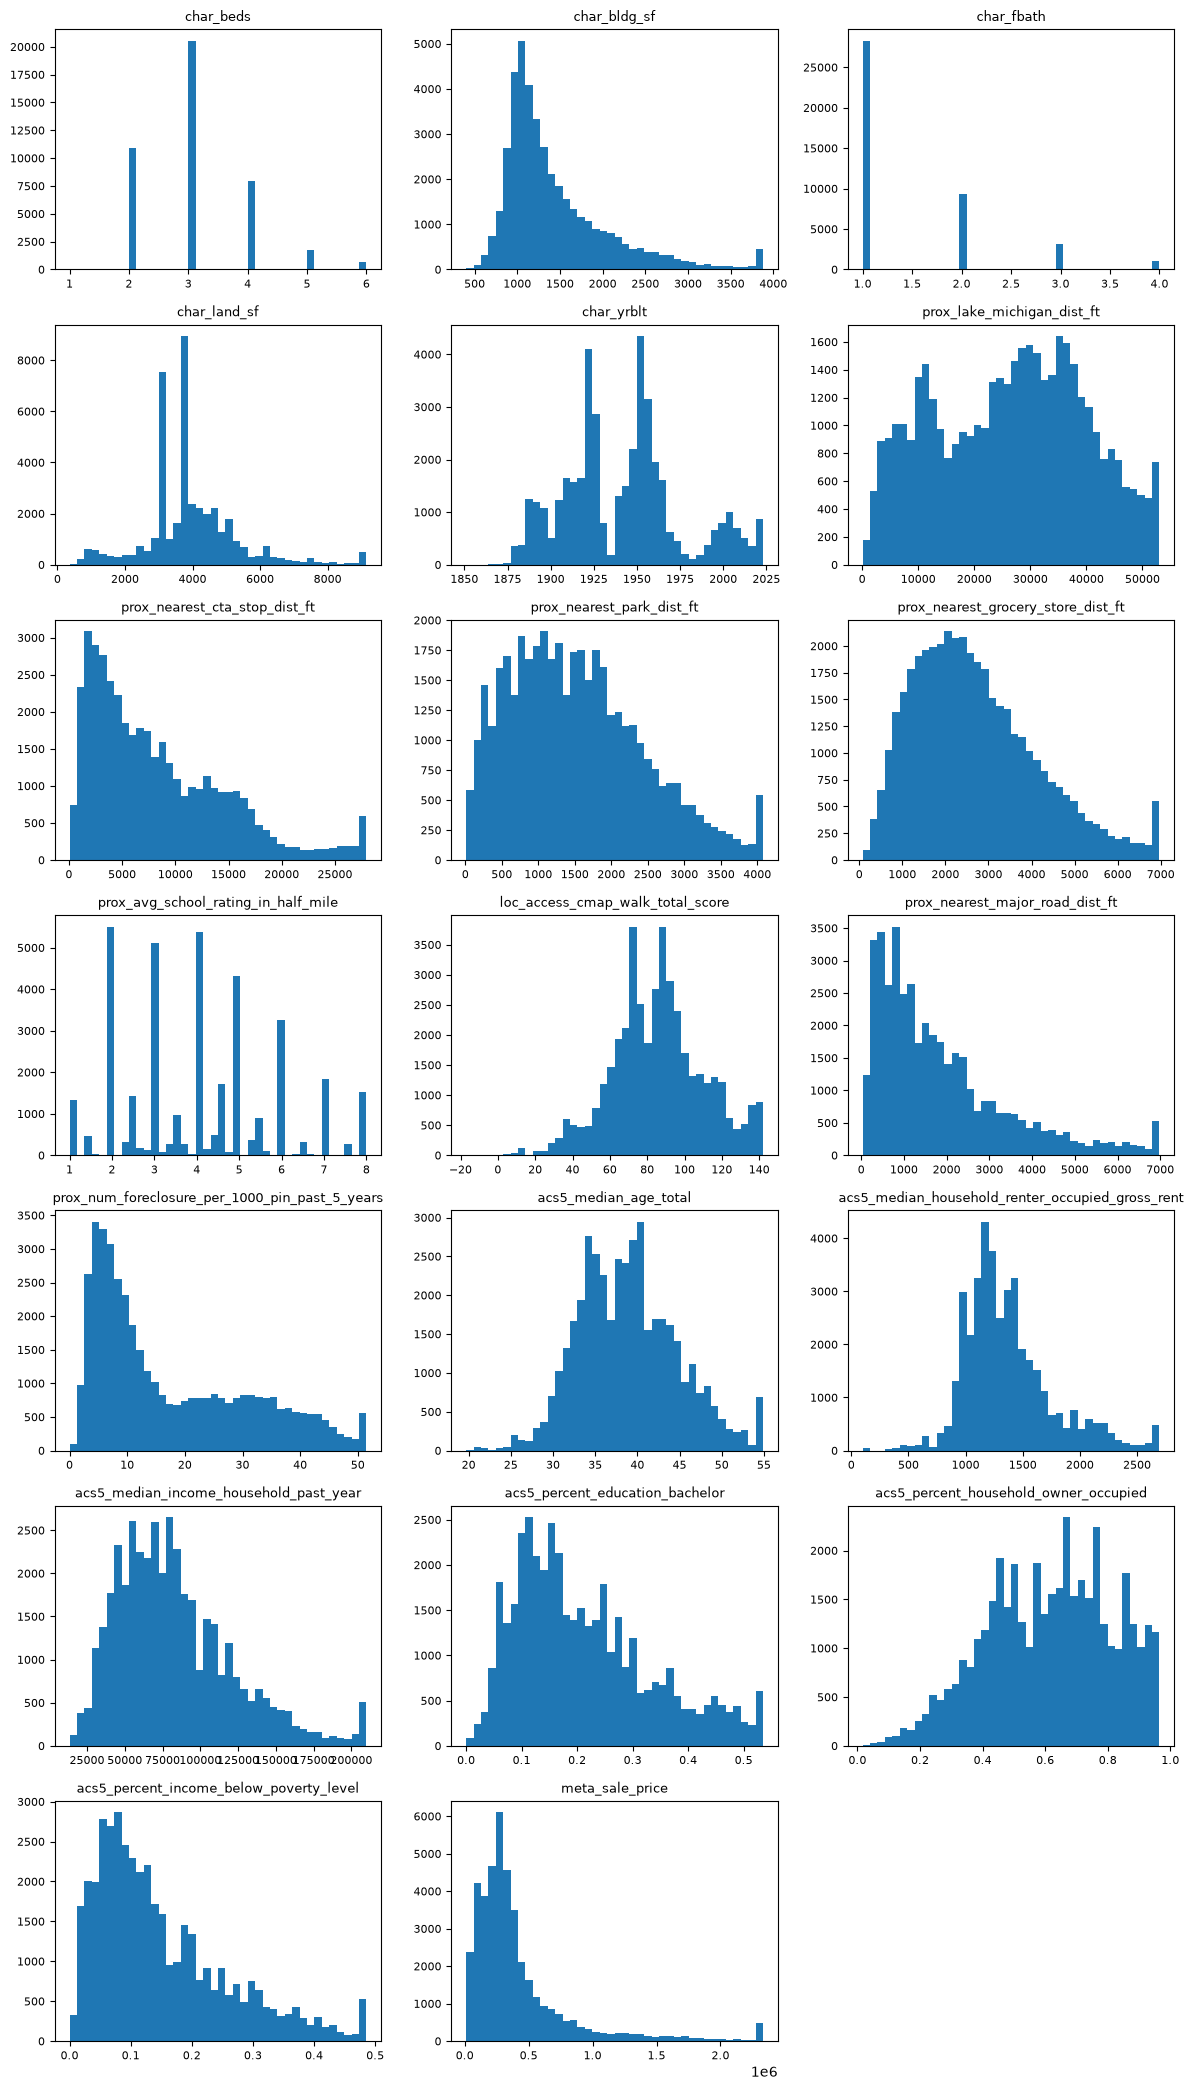

In [6]:
# Step 3 — examine distributions of the cleaned numeric columns: decide transforms,
# spot heavy tails. summarize_distributions() = the decision table (skew, tail_ratio,
# transform_hint); plot_distributions() = the shapes.
# Guide on skew and kurtosis: https://library.soton.ac.uk/skewness-and-kurtosis
df_clean = wrangling.drop_redundant_columns(wrangling.convert_float_to_int(df), verbose=False)
summary = distributions.summarize_distributions(df_clean, candidate)
display(summary)

distributions.plot_distributions(df_clean, [c for c in candidate if c in df_clean.columns])
plt.show()

### 2. Outlier / sanity analysis (report + label, no drops)
We hunt **data errors** (impossible values), *not* the genuine price-extreme tails we deliberately keep. Five lenses: (1) plausibility-bound counts, (2) price-per-sqft, (3) price-per-bedroom, (4) log-scale IQR fences, (5) boxplots + price scatter. Nothing is dropped — rows are flagged for review.

In [7]:
# Numeric vars to scrutinize for data errors
outlier_vars = ['char_bldg_sf', 'char_land_sf', 'char_beds', 'char_fbath', 'char_yrblt', 'meta_sale_price']

# (1) logical plausibility counts — rows outside constants.SANITY_BOUNDS
display(wrangling.sanity_checks(df))

# (2) + (3) price ratios (tighter lens than price alone) + their band flags
df = wrangling.add_price_ratios(df)   # price_per_bldg_sqft, price_per_land_sqft, price_per_bed (+ flags)
display(df[['price_per_bldg_sqft', 'price_per_land_sqft', 'price_per_bed']].describe(percentiles=[.01, .5, .99]))
print('ratio-band outliers:', int(df['is_ppsf_outlier'].sum()), 'bldg $/sqft |',
      int(df['is_ppbed_outlier'].sum()), '$/bed')

# (4) log-scale Tukey fences — an INSPECTION list (genuine tails trip it too, by design)
log_iqr = wrangling.flag_log_iqr(df, outlier_vars)
display(log_iqr.sum().rename('n_log_iqr_out').to_frame())

,column,lo,hi,n_below,n_above,n_null,n_flagged,pct_flagged
0,char_bldg_sf,50,"20,000.000",0,0,2,0,0.000
1,char_land_sf,50,"30,000.000",0,1,1,1,0.000
2,char_beds,1,12.000,0,0,4,0,0.000
3,char_fbath,1,10.000,0,0,4,0,0.000
4,char_yrblt,1850,"2,025.000",0,0,0,0,0.000
5,meta_sale_price,10000,NaN,0,0,0,0,0.000


,price_per_bldg_sqft,price_per_land_sqft,price_per_bed
count,"41,760.000","41,761.000","41,758.000"
mean,267.963,136.990,"133,481.888"
std,167.088,189.647,"113,787.922"
min,5.597,1.600,"2,400.000"
1%,27.357,8.065,"11,000.000"
50%,246.137,74.667,"106,333.333"
99%,797.784,948.421,"561,191.667"
max,"3,366.316","3,037.634","2,541,666.667"


ratio-band outliers: 182 bldg $/sqft | 33 $/bed


,n_log_iqr_out
char_bldg_sf_log_iqr_out,697
char_land_sf_log_iqr_out,3161
char_beds_log_iqr_out,711
char_fbath_log_iqr_out,52
char_yrblt_log_iqr_out,795
meta_sale_price_log_iqr_out,1662


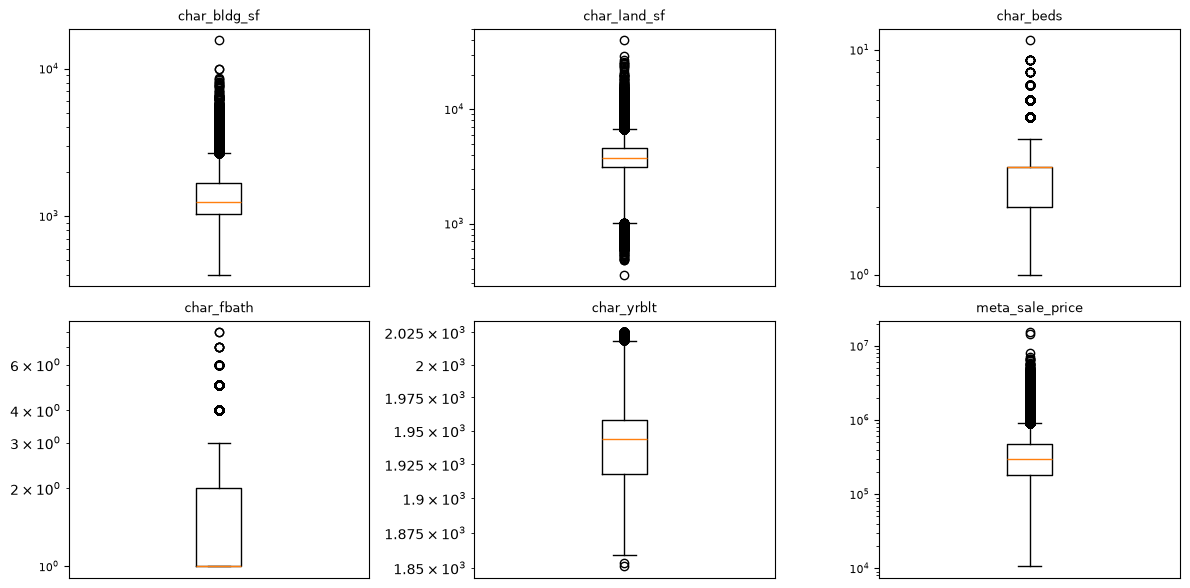

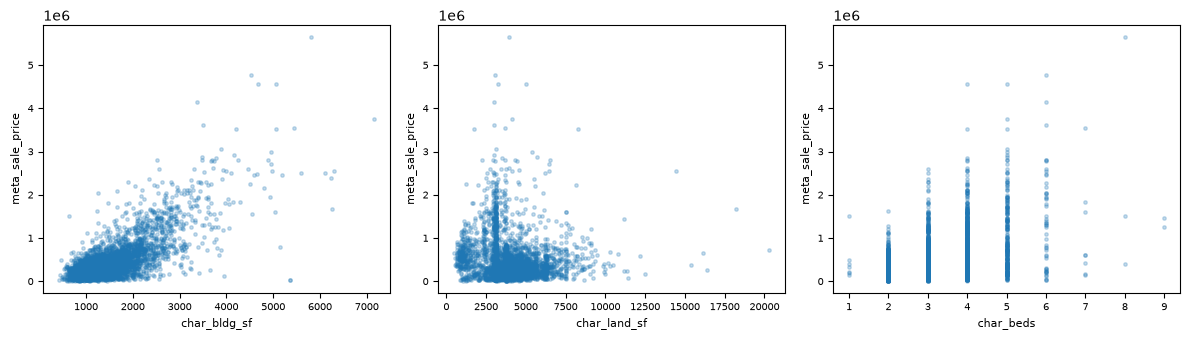

In [8]:
# (4) boxplots  and  (5) scatter vs price — data errors sit OFF the cloud, genuine extremes ON the trend
distributions.plot_boxplots(df, outlier_vars, log=True)
distributions.plot_scatter(df, ['char_bldg_sf', 'char_land_sf', 'char_beds'], y=K.TARGET_RAW)
plt.show()

In [9]:
# Eyeball the rows BEHIND the flags — is each a data error or a genuine extreme?
show = ['meta_pin', K.REPORT_GEO, 'meta_year', K.TARGET_RAW,
        'char_bldg_sf', 'char_land_sf', 'char_beds', 'char_yrblt', 'price_per_bldg_sqft', 'price_per_bed']

print('Highest bldg $/sqft (luxury vs price/size error):')
display(df.loc[df['is_ppsf_outlier'], show].nlargest(10, 'price_per_bldg_sqft'))

print('Lowest bldg $/sqft (teardown / nominal-price error):')
display(df.loc[df['is_ppsf_outlier'], show].nsmallest(10, 'price_per_bldg_sqft'))

Highest bldg $/sqft (luxury vs price/size error):


,meta_pin,loc_chicago_community_area_name,meta_year,meta_sale_price,char_bldg_sf,char_land_sf,char_beds,char_yrblt,price_per_bldg_sqft,price_per_bed
127755,13134080290000,NORTH CENTER,2025,"1,599,000.000",475.000,"3,125.000",1.000,"1,903.000","3,366.316","1,599,000.000"
291306,14311060210000,LOGAN SQUARE,2023,"1,930,000.000",600.000,"2,400.000",2.000,"1,890.000","3,216.667","965,000.000"
365235,25052000450000,AUBURN GRESHAM,2024,"20,000.000","1,001.000","2,665.000",2.000,"1,971.000",19.980,"10,000.000"
59437,25281250150000,WEST PULLMAN,2024,"22,500.000","1,130.000","3,075.000",4.000,"1,898.000",19.912,"5,625.000"
145669,16023130310000,HUMBOLDT PARK,2022,"28,000.000","1,408.000","4,687.000",2.000,"1,888.000",19.886,"14,000.000"
226431,20184220310000,WEST ENGLEWOOD,2023,"18,000.000",906.000,"3,100.000",2.000,"1,909.000",19.868,"9,000.000"
368913,25281180300000,WEST PULLMAN,2023,"38,000.000","1,913.000","3,690.000",3.000,"1,898.000",19.864,"12,666.667"
378895,25153110030000,ROSELAND,2024,"25,000.000","1,260.000","3,402.000",4.000,"1,888.000",19.841,"6,250.000"
23760,20204050480000,ENGLEWOOD,2022,"19,900.000","1,008.000",841.000,3.000,"1,878.000",19.742,"6,633.333"
167897,21311030610000,SOUTH CHICAGO,2025,"18,000.000",912.000,"4,353.000",2.000,"1,915.000",19.737,"9,000.000"


Lowest bldg $/sqft (teardown / nominal-price error):


,meta_pin,loc_chicago_community_area_name,meta_year,meta_sale_price,char_bldg_sf,char_land_sf,char_beds,char_yrblt,price_per_bldg_sqft,price_per_bed
93213,20282020060000,GREATER GRAND CROSSING,2023,"30,000.000","5,360.000","2,067.000",6.000,"1,882.000",5.597,"5,000.000"
272575,20282020050000,GREATER GRAND CROSSING,2023,"30,000.000","5,360.000","2,067.000",6.000,"1,882.000",5.597,"5,000.000"
234009,20294220060000,AUBURN GRESHAM,2023,"15,000.000","2,406.000","5,000.000",4.000,"1,893.000",6.234,"3,750.000"
335305,25292100170000,WEST PULLMAN,2024,"10,639.000","1,680.000","2,556.000",4.000,"1,960.000",6.333,"2,659.750"
49152,16151060290000,WEST GARFIELD PARK,2025,"11,000.000","1,620.000","3,050.000",3.000,"1,920.000",6.790,"3,666.667"
258917,20213270150000,ENGLEWOOD,2023,"13,500.000","1,960.000","4,250.000",5.000,"1,893.000",6.888,"2,700.000"
202488,16222080260000,NORTH LAWNDALE,2024,"11,500.000","1,577.000","3,125.000",3.000,"2,005.000",7.292,"3,833.333"
326823,20202030320000,ENGLEWOOD,2023,"15,000.000","2,004.000","3,125.000",4.000,"1,912.000",7.485,"3,750.000"
186323,20282020060000,GREATER GRAND CROSSING,2025,"42,000.000","5,360.000","2,067.000",6.000,"1,882.000",7.836,"7,000.000"
30758,20282100220000,GREATER GRAND CROSSING,2022,"22,000.000","2,666.000","6,200.000",4.000,"1,889.000",8.252,"5,500.000"


### 3. New Features & Transformations

In [10]:
# --- Derived prep-stage variables ---------------------------------------------
# Pattern: encode each NEW variable as a function in features/derive.py (reusable
# and testable), then call it here — never as a one-off cell computation. Run
# after recode_categoricals since the flag reads the 'char_gar1_size' label.
df = derive.add_gar1_exists_flag(df)     # 1 if any garage (char_gar1_size != '0 cars')
df['char_gar1_exists'].value_counts(dropna=False)

char_gar1_exists
1       33233
0        8514
<NA>       15
Name: count, dtype: Int64

In [11]:
# Log transforms — new columns for the regression iterations (log price, land, bldg)
df = derive.add_log_features(df)     # log_char_bldg_sf, log_char_land_sf, log_income (curvature predictors)
df = wrangling.add_log_target(df)    # log_sale_price (the modeled target)
df[['meta_sale_price', 'log_sale_price', 'log_char_bldg_sf', 'log_char_land_sf']].head()

,meta_sale_price,log_sale_price,log_char_bldg_sf,log_char_land_sf
114,"148,500.000",11.908,6.947,8.221
115,"255,000.000",12.449,6.947,7.919
116,"294,994.000",12.595,7.172,8.047
117,"765,000.000",13.548,7.803,8.795
118,"59,000.000",10.985,6.652,8.566


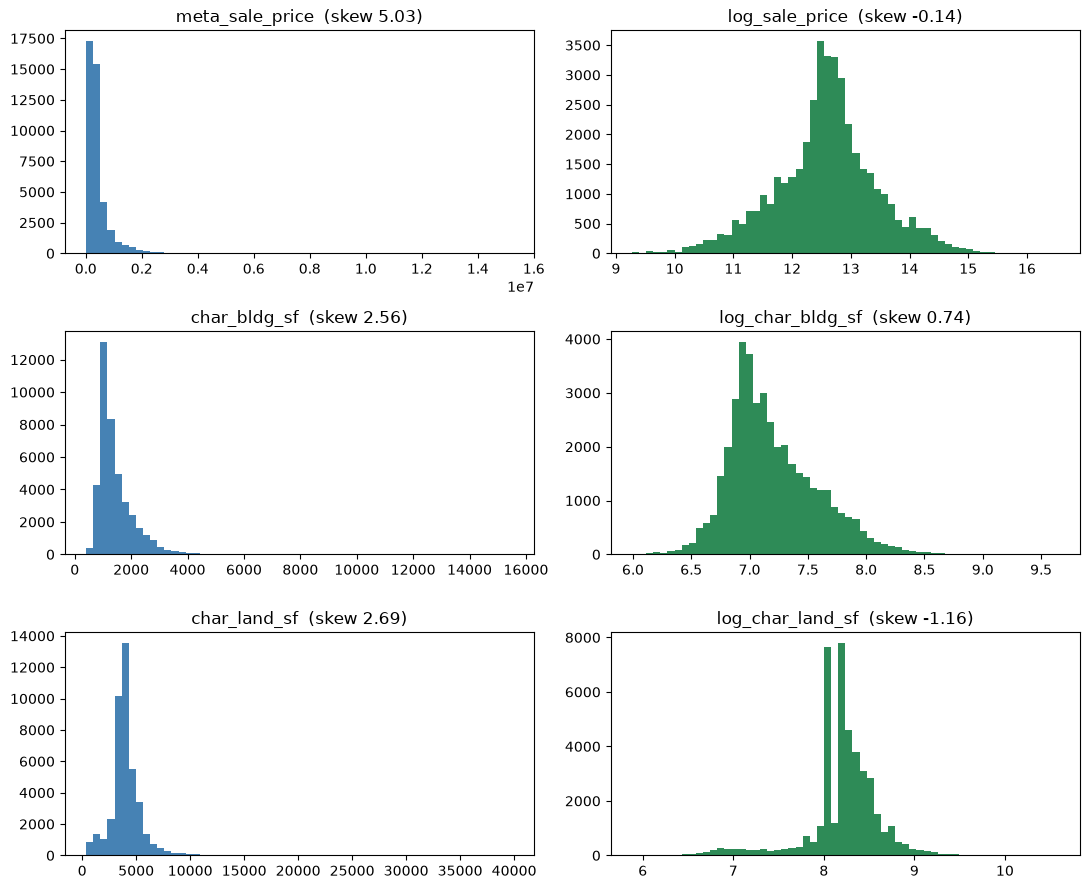

In [12]:
# Compare each original feature with its log version (raw skew vs post-log symmetry)
# Pairs: the modeled target + every log_* column add_log_features created.
log_pairs = [('meta_sale_price', 'log_sale_price')]
log_pairs += [(c[len('log_'):], c) for c in df.columns
              if c.startswith('log_') and c[len('log_'):] in df.columns]

fig, axes = plt.subplots(len(log_pairs), 2, figsize=(11, 3 * len(log_pairs)))
axes = np.atleast_2d(axes)
for (raw_col, log_col), (ax_raw, ax_log) in zip(log_pairs, axes):
    raw_vals = df[raw_col].replace([np.inf, -np.inf], np.nan).dropna()
    log_vals = df[log_col].replace([np.inf, -np.inf], np.nan).dropna()
    ax_raw.hist(raw_vals, bins=60, color='steelblue')
    ax_raw.set_title(f'{raw_col}  (skew {raw_vals.skew():.2f})')
    ax_log.hist(log_vals, bins=60, color='seagreen')
    ax_log.set_title(f'{log_col}  (skew {log_vals.skew():.2f})')
fig.tight_layout()
plt.show()

### 4. Sale classification
Flag each sale by its validity reasons (`wrangling.classify_sales`) and preview which the drop policy would remove. **We do not drop here** — the drop happens inside `build_analytic_sample` in §5. Counts are per-reason and NOT mutually exclusive.

In [13]:
# Classify sales by validity flags (logic in wrangling.classify_sales)
flags = wrangling.classify_sales(df)
enriched = df.join(flags)
enriched['meta_sale_date'] = pd.to_datetime(enriched['meta_sale_date'])
enriched['sale_month'] = enriched['meta_sale_date'].dt.month

# preview the population the drop policy WOULD remove (not applied here — §5 does that)
kept = wrangling.apply_drop_policy(df, flags)
print(f"policy would drop {len(df) - len(kept):,} of {len(df):,} sales")

apply_drop_policy: 41,762 -> 38,578
  statutory (PTAX/family): 2,250
  below $10,000 floor:    0
  entity + price-corrob.:  1,288
policy would drop 3,184 of 41,762 sales


In [14]:
# Flag counts (per-reason, NOT mutually exclusive)
for f in ['is_statutory', 'is_entity', 'is_nominal', 'is_stale', 'is_below_floor']:
    print(f"{f:16s}", dict(enriched[f].value_counts()))

is_statutory     {False: np.int64(39512), True: np.int64(2250)}
is_entity        {np.False_: np.int64(21290), np.True_: np.int64(20472)}
is_nominal       {False: np.int64(40092), True: np.int64(1670)}
is_stale         {False: np.int64(38742), True: np.int64(3020)}
is_below_floor   {False: np.int64(41762)}


### 5. Build the analytic sample
The reproducible all-in-one: `build_analytic_sample` runs every step above (scope → recode → drop non-market → features → logs → drop null target) behind one call. Flip any keyword to `False` for regression iterations (e.g. `add_logs=False`, `drop_non_market=False`).

In [15]:
sample = wrangling.build_analytic_sample(raw)
print('analytic sample:', sample.shape)
sample.head()

scope_filter:         396,480 ->   41,762 rows
recode_categoricals: 10 col(s) -> labels: ['char_air', 'char_attic_fnsh', 'char_attic_type', 'char_bsmt', 'char_bsmt_fin', 'char_gar1_att', 'char_gar1_size', 'char_heat', 'char_porch', 'char_roof_cnst']
apply_drop_policy: 41,762 -> 38,578
  statutory (PTAX/family): 2,250
  below $10,000 floor:    0
  entity + price-corrob.:  1,288
analytic sample:                38,578 rows
analytic sample: (38578, 52)


,meta_sale_price,meta_sale_seller_name,meta_sale_buyer_name,meta_sale_date,meta_year,sv_outlier_reason1,sv_outlier_reason2,sv_outlier_reason3,char_air,char_attic_fnsh,...,loc_longitude,loc_x_3435,loc_y_3435,loc_chicago_community_area_name,dist_to_loop_ft,no_rated_school_nearby,char_gar1_exists,log_char_bldg_sf,log_char_land_sf,log_sale_price
114,"148,500.000",JOSEPH GATTON NOT INDIVIDUALLY BUT AS INDEPEND...,"CHGO HOME HELPERS, INC.",2023-09-14,2023,Non-person sale,NaN,NaN,No Central A/C,None,...,-87.558,"1,196,003.775","1,820,072.933",HEGEWISCH,"82,007.308",0,1,6.947,8.221,11.908
115,"255,000.000","NH INVESTMENT ADVISOR, LLC",LAURA KARINA SANCHEZ,2023-02-16,2023,Short-term owner,Non-person sale,NaN,No Central A/C,None,...,-87.558,"1,195,988.930","1,821,266.730",HEGEWISCH,"80,853.171",0,1,6.947,7.919,12.449
116,"294,994.000","CTZMIX PROPERTY SERVICES, INC",RICHARD SHORTER,2023-04-21,2023,Non-person sale,NaN,NaN,Central A/C,None,...,-87.587,"1,187,952.513","1,844,478.065",CALUMET HEIGHTS,"56,353.892",0,1,7.172,8.047,12.595
117,"765,000.000",BERNARD M. BURKE,CHRISTOPHER G ENOE,2023-02-23,2023,NaN,NaN,NaN,Central A/C,None,...,-87.676,"1,163,693.733","1,838,408.985",BEVERLY,"61,613.728",0,1,7.803,8.795,13.548
119,"177,000.000","JN ENTERPRISES, INC.",MARITZA HUERTA,2023-10-27,2023,Short-term owner,Non-person sale,NaN,No Central A/C,None,...,-87.656,"1,169,312.470","1,823,577.690",WEST PULLMAN,"75,702.584",0,1,6.652,8.566,12.084
